In [1]:
using JLD2
using PyPlot
using Statistics
using HDF5
using Interpolations
using LsqFit

### Load data from Julian simulations

In [2]:
pathname_sim_julian = "Density_distributions/Groundstate_Bext_90_deg_as_98.h5"
file = h5open(pathname_sim_julian, "r")
n = read(file["n"])
nxy = read(file["nxy"])
nxz = read(file["nxz"])
x = read(file["x"])
y = read(file["y"])
z = read(file["z"])
dx, dy, dz = read(file["dx"])[1], read(file["dy"])[1], read(file["dz"])[1]
N = 30;

### Find boundaries of the CS

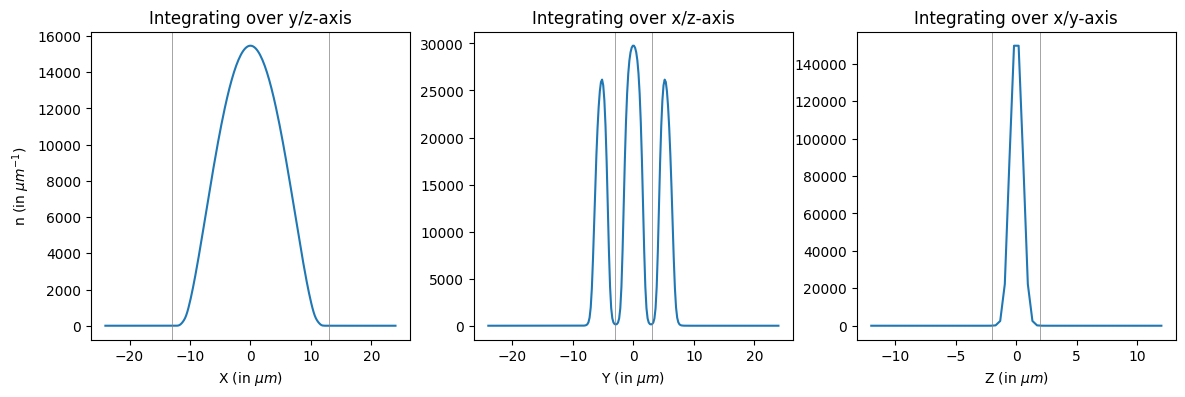

In [3]:
close("all")
fig, axes = subplots(1, 3, figsize=(14, 4))

axes[1].plot(x', sum(nxy, dims=2).*dy)
axes[2].plot(y', sum(nxy, dims=1)'.*dx, label="Integrating over x/z-axis")
axes[3].plot(z', sum(nxz, dims=1)'.*dx, label="Integrating over x/z-axis")

axes[1].axvline(-13, color="grey", linewidth=0.5), axes[1].axvline(13, color="grey", linewidth=0.5)
axes[2].axvline(-3, color="grey", linewidth=0.5), axes[2].axvline(3, color="grey", linewidth=0.5)
axes[3].axvline(-2, color="grey", linewidth=0.5), axes[3].axvline(2, color="grey", linewidth=0.5)

axes[1].title.set_text("Integrating over y/z-axis")
axes[2].title.set_text("Integrating over x/z-axis")
axes[3].title.set_text("Integrating over x/y-axis")

axes[1].set_xlabel(L"X (in $\mu m$)")
axes[2].set_xlabel(L"Y (in $\mu m$)")
axes[3].set_xlabel(L"Z (in $\mu m$)")

axes[1].set_ylabel(L"n (in $\mu m^{-1}$)")

# pygui(true); show();
pygui(false);

### Cut the central stripe

In [4]:
mask_xy = ((x.>-13) .* (x.<13))' * ((y.>-3) .* (y.<3))
mask_z = ((z.>-2) .* (z.<2))
mask_CS = mask_xy .* reshape(mask_z, 1, 1, length(mask_z))
n_CS = n .* mask_CS;

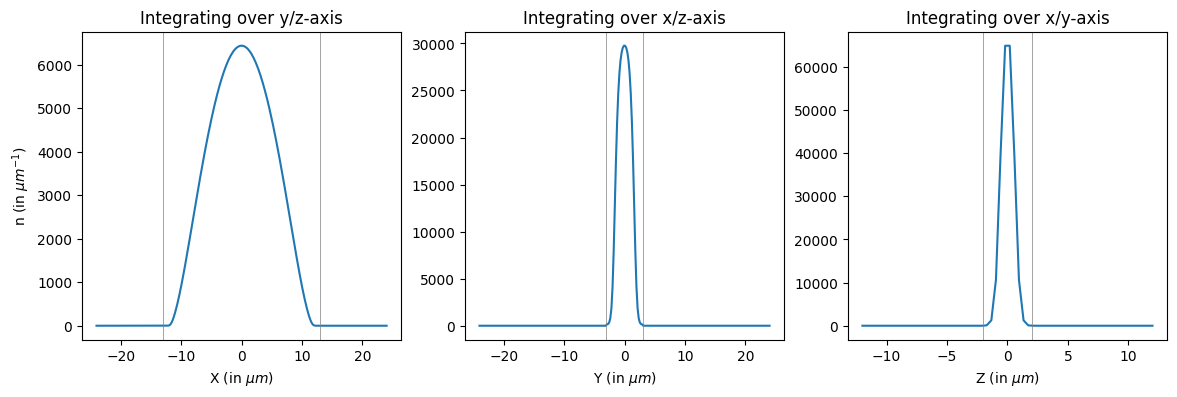

In [5]:
close("all")
fig, axes = subplots(1, 3, figsize=(14, 4))

axes[1].plot(x', reshape(sum(sum(n_CS, dims=3) .*dz, dims=2).*dy, length(x)))
axes[2].plot(y', reshape(sum(sum(n_CS, dims=3) .*dz, dims=1).*dx, length(y)))
axes[3].plot(z', reshape(sum(sum(n_CS, dims=2) .*dy, dims=1).*dx, length(z)))

axes[1].axvline(-13, color="grey", linewidth=0.5), axes[1].axvline(13, color="grey", linewidth=0.5)
axes[2].axvline(-3, color="grey", linewidth=0.5), axes[2].axvline(3, color="grey", linewidth=0.5)
axes[3].axvline(-2, color="grey", linewidth=0.5), axes[3].axvline(2, color="grey", linewidth=0.5)

axes[1].title.set_text("Integrating over y/z-axis")
axes[2].title.set_text("Integrating over x/z-axis")
axes[3].title.set_text("Integrating over x/y-axis")

axes[1].set_xlabel(L"X (in $\mu m$)")
axes[2].set_xlabel(L"Y (in $\mu m$)")
axes[3].set_xlabel(L"Z (in $\mu m$)")

axes[1].set_ylabel(L"n (in $\mu m^{-1}$)")

# pygui(true); show();
pygui(false);

### Fit to get the stripe size

In [6]:
gaussian(x, p) = p[1]*exp.(-(x/p[2]).^2)

p0 = [6000., 10.] # Max density, σ gaussian
fit = curve_fit(gaussian, reshape(x, length(x)), reshape(sum(sum(n_CS, dims=3) .*dz, dims=2).*dy, length(x)), p0)
println("Half x-axis = $(fit.param[2]) um")

p0 = [30000., 2.] # Max density, σ gaussian
fit = curve_fit(gaussian, reshape(y, length(y)), reshape(sum(sum(n_CS, dims=3) .*dz, dims=1).*dx, length(y)), p0)
println("Half y-axis = $(fit.param[2]) um");

Half x-axis = 7.630504388680256 um
Half y-axis = 1.5864096721914764 um


## Plot the density distribution of the CS

In [7]:
sorted_density_distrib = sort(reshape(n_CS, length(x)*length(y)*length(z)));

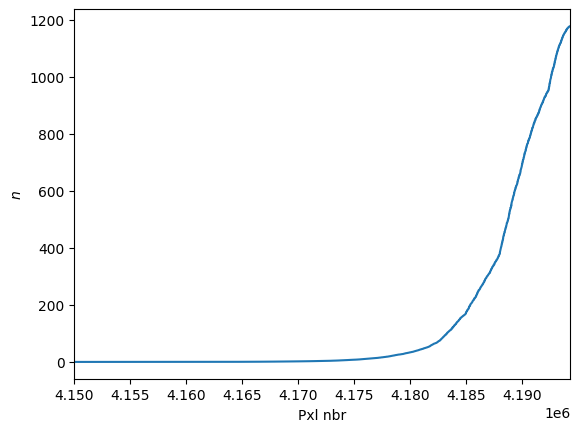

In [8]:
close("all")
fig = subplot()

plot([1:length(sorted_density_distrib);], sorted_density_distrib)

xlabel("Pxl nbr")
ylabel(L"n")

xlim(4.15e6, length(sorted_density_distrib))

# pygui(true); show();
pygui(false);

In [9]:
# Compute density cuts when nbr of atoms = N
CS_densities_cuts = []
pxl_nbr_CS_densities_cuts = []

atom_counter = 0
for i = 1:length(sorted_density_distrib)
    atom_counter += sorted_density_distrib[i] *dx*dy*dz
    if atom_counter > N
        push!(CS_densities_cuts, sorted_density_distrib[i])
        push!(pxl_nbr_CS_densities_cuts, i)
        atom_counter = 0
    end
end

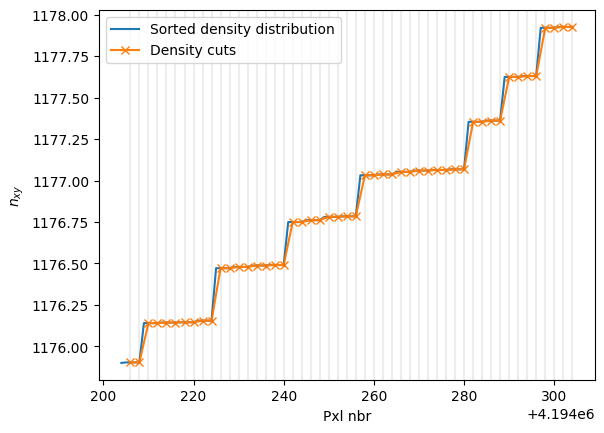

In [10]:
close("all")
fig = subplot()

x_lb = 100

plot([length(sorted_density_distrib)-x_lb:length(sorted_density_distrib);], sorted_density_distrib[end-x_lb:end], label="Sorted density distribution")
plot(pxl_nbr_CS_densities_cuts[pxl_nbr_CS_densities_cuts.>length(sorted_density_distrib)-x_lb], CS_densities_cuts[pxl_nbr_CS_densities_cuts.>length(sorted_density_distrib)-x_lb], label="Density cuts", marker="x")

for pxl_cut in pxl_nbr_CS_densities_cuts[pxl_nbr_CS_densities_cuts.>length(sorted_density_distrib)-x_lb]
    axvline(pxl_cut, linewidth=0.1, color="black")
end

xlabel("Pxl nbr")
ylabel(L"n_{xy}")

legend()

# pygui(true); show()
pygui(false);

In [11]:
println("Maximum atom nbr per step = $(CS_densities_cuts[end]*dx*dy*dz)")

Maximum atom nbr per step = 15.89977083551677


### Interpolate the density distribution

In [52]:
step_itp = 1e-1
pxl_interpolation = [1:step_itp:length(sorted_density_distrib);]
itp = linear_interpolation([1:length(sorted_density_distrib);], sorted_density_distrib)
interpolated_density_distribution = itp(pxl_interpolation);

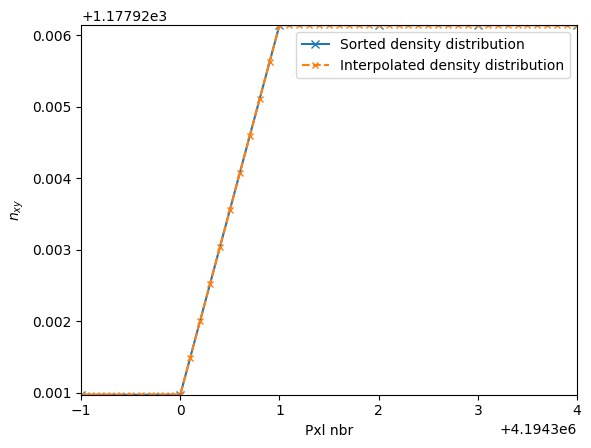

In [53]:
close("all")
fig = subplot()

plot([1:length(sorted_density_distrib);], sorted_density_distrib, label="Sorted density distribution", marker="x")
plot(pxl_interpolation, interpolated_density_distribution, label="Interpolated density distribution", marker="x", markersize=4, linestyle="--")

xlim(pxl_interpolation[end-50], pxl_interpolation[end])
ylim(interpolated_density_distribution[end-50], interpolated_density_distribution[end])

xlabel("Pxl nbr")
ylabel(L"n_{xy}")

legend()

# pygui(true); show()
pygui(false);

In [54]:
# Compute density cuts when nbr of atoms = N
CS_densities_cuts = []
pxl_nbr_CS_densities_cuts = []

atom_counter = 0
for i = 1:length(interpolated_density_distribution)
    atom_counter += interpolated_density_distribution[i] *dx*dy*dz*step_itp
    if atom_counter > N
        push!(CS_densities_cuts, interpolated_density_distribution[i])
        push!(pxl_nbr_CS_densities_cuts, pxl_interpolation[i])
        atom_counter = 0
    end
end

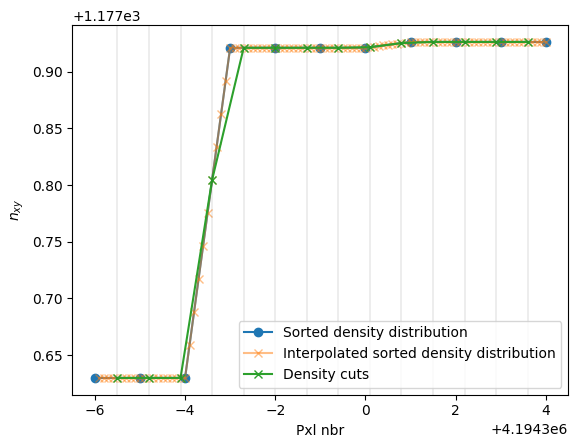

In [55]:
close("all")
fig = subplot()

x_lb = 10

plot([length(sorted_density_distrib)-x_lb:length(sorted_density_distrib);], sorted_density_distrib[end-x_lb:end], label="Sorted density distribution", marker="o")
plot(pxl_interpolation[pxl_interpolation.>length(sorted_density_distrib)-x_lb], interpolated_density_distribution[pxl_interpolation.>length(sorted_density_distrib)-x_lb], label="Interpolated sorted density distribution", marker="x", alpha=0.5)
plot(pxl_nbr_CS_densities_cuts[pxl_nbr_CS_densities_cuts.>length(sorted_density_distrib)-x_lb], CS_densities_cuts[pxl_nbr_CS_densities_cuts.>length(sorted_density_distrib)-x_lb], label="Density cuts", marker="x")

for pxl_cut in pxl_nbr_CS_densities_cuts[pxl_nbr_CS_densities_cuts.>length(sorted_density_distrib)-x_lb]
    axvline(pxl_cut, linewidth=0.1, color="black")
end

xlabel("Pxl nbr")
ylabel(L"n_{xy}")

legend()

# pygui(true); show()
pygui(false);

In [56]:
println("Maximum atom nbr per step = $(CS_densities_cuts[end]*dx*dy*dz*step_itp)")

Maximum atom nbr per step = 1.5899770835516758


### Normalize by λ 

In [12]:
λ = 421e-9 # Lambda im m
CS_densities_cuts_norm = CS_densities_cuts * (λ/1e-6)^3; # Density of atoms per unit of volume lambda^3

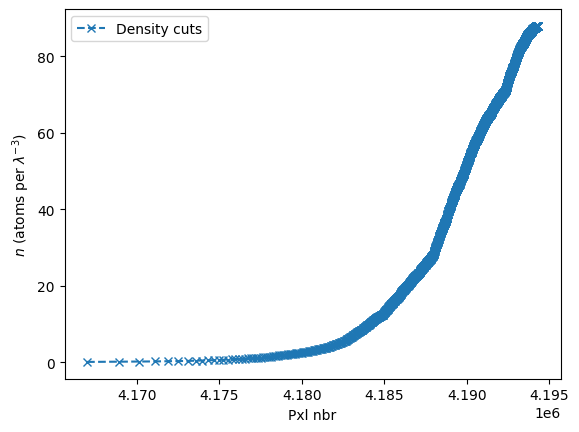

In [13]:
close("all")
fig = subplot()

plot(pxl_nbr_CS_densities_cuts, CS_densities_cuts_norm, label="Density cuts", linestyle="--", marker="x")
xlabel("Pxl nbr")
ylabel(L"$n$ (atoms per $\lambda^{-3}$)")

legend()
# pygui(true); show()
pygui(false);

In [14]:
@save "$(pathname_sim_julian[1:end-3])_N_$(N).jld2" CS_densities_cuts_norm

In [60]:
@load "$(pathname_sim_julian[1:end-3])_N_$(N).jld2" CS_densities_cuts_norm;

In [61]:
println("Nbr atoms in CS = $(sum(n_CS)*dx*dy*dz)")

Nbr atoms in CS = 88670.92833127192


In [15]:
println("Nbr atoms simulated = $(N*length(CS_densities_cuts_norm))")

Nbr atoms simulated = 77790
